# Quantum Tree Generator (QTG) for 0-1 Knapsack

implementation of the QTG algorithm from:
*"A quantum algorithm for solving 0-1 Knapsack problems"*,
Wilkening et al., npj Quantum Information (2025)

### 4-item instance

| Item | Weight | Profit | Density |
|:----:|:------:|:------:|:-------:|
|  0   |   5    |   7    |  1.40   |
|  1   |   3    |   4    |  1.33   |
|  2   |   4    |   5    |  1.25   |
|  3   |   2    |   1    |  0.50   |

Capacity = 7. Greedy takes items 0 and 3 (profit 8). Optimal is items 1 and 2 (profit 9).

In [22]:

import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.synthesis.qft import synth_qft_full
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit.visualization import plot_histogram

In [23]:
# ============================================================
# Cell 2 -- Problem setup
# ============================================================
#
# Items are pre-sorted by decreasing profit/weight density,
# as prescribed by the paper's classical preprocessing step.
#
# The greedy algorithm walks through the sorted list and takes
# each item if it still fits.  For this instance the greedy
# solution is SUB-OPTIMAL, which makes the problem interesting:
# the QTG + amplification must find a solution the greedy missed.

weights  = [5, 3, 4, 2]       # already sorted by density
profits  = [7, 4, 5, 1]
capacity = 7
n_items  = len(weights)        

# ---- Register sizing ----
#
# CAPACITY register (n_cap qubits):
#   Must hold values 0....c and allow the MSB sign trick.
#   Rule: 2^(n_cap-1) > capacity  AND  2^(n_cap-1) > max(weights).
#   capacity=7, max weight=5.  2^3 = 8 > 7 and 8 > 5.  So n_cap=4.
#
# PROFIT register (n_prof qubits):
#   The oracle subtracts the threshold and checks the MSB.
#   Rule: 2^(n_prof-1) > threshold.
#   Threshold will be 9 (greedy_profit+1).  2^4 = 16 > 9.  So n_prof=5.
#


n_cap  = 4    # 4 qubits for remaining capacity  (values 0..15)
n_prof = 5    # 5 qubits for accumulated profit   (values 0..31)

# ---- Greedy solution ----
# Walk through sorted items, take each if it fits:
#   item 0 (w=5): take, remaining = 2
#   item 1 (w=3): skip  (3 > 2)
#   item 2 (w=4): skip  (4 > 2)
#   item 3 (w=2): take, remaining = 0
# Greedy = [1,0,0,1], profit = 7+1 = 8

greedy_solution = [1, 0, 0, 1]
greedy_profit   = 8

# Threshold: look for solutions strictly better than greedy.
threshold = greedy_profit + 1   # 9

# ---- Bias parameter (Eq. 5) ----
# Paper uses Delta=4, giving b = n/Delta = n/4.
#Δ tells the algorithm how far away, in number of changed 
# item choices, a promising solution is expected to be from 
# the current one; they set Δ=4 because that tuning worked well in practice.

b = n_items / 4   # 1.0

print(f'Items (sorted):  weights={weights}, profits={profits}')
print(f'Capacity: {capacity}')
print(f'Greedy: {greedy_solution}  profit={greedy_profit}')
print(f'Threshold: profit >= {threshold}')
print(f'Bias b = {b}')
print(f'Registers: n_cap={n_cap}, n_prof={n_prof}')
print(f'Total qubits: {n_items}+{n_cap}+{n_prof}+1 = {n_items+n_cap+n_prof+1}')

Items (sorted):  weights=[5, 3, 4, 2], profits=[7, 4, 5, 1]
Capacity: 7
Greedy: [1, 0, 0, 1]  profit=8
Threshold: profit >= 9
Bias b = 2.0
Registers: n_cap=4, n_prof=5
Total qubits: 4+4+5+1 = 14


In [24]:
# ============================================================
# Cell 3 -- Biased Ry angles  (Eq. 3 of the paper)
# ============================================================
#
# For each item m, the QTG applies a BIASED Ry rotation
# (not a balanced Hadamard) whose angle depends on whether
# the greedy solution took that item.
#
# greedy_bit = 1  (greedy took item m):
#   theta = 2*arccos( sqrt(1/(2+b)) )
#   P(include) = (1+b)/(2+b)   -- favours inclusion
#   P(exclude) =   1  /(2+b)
#
# greedy_bit = 0  (greedy skipped item m):
#   theta = 2*arccos( sqrt((1+b)/(2+b)) )
#   P(include) =   1  /(2+b)   -- favours exclusion
#   P(exclude) = (1+b)/(2+b)
#
# Effect: paths close (in Hamming distance) to the greedy
# solution get higher amplitude, giving amplification a head
# start.  For this instance the optimal [0,1,1,0] is at
# Hamming distance 4 from the greedy [1,0,0,1], so it starts
# with very low amplitude -- exactly the scenario where Grover
# amplification shines.

def ry_angle(greedy_bit, b):
    """Biased Ry angle for one item"""
    if greedy_bit == 0:
        return 2 * np.arccos(np.sqrt((1 + b) / (2 + b)))
    else:
        return 2 * np.arccos(np.sqrt(1 / (2 + b)))

# Show the angles and probabilities for each item in the greedy solution
for m in range(n_items):
    theta = ry_angle(greedy_solution[m], b)
    p_inc = np.sin(theta / 2) ** 2
    print(f'Item {m}: w={weights[m]}, p={profits[m]}, '
          f'greedy={greedy_solution[m]}, '
          f'theta={theta:.4f}, '
          f'P(incl)={p_inc:.4f}, P(excl)={1-p_inc:.4f}')

Item 0: w=5, p=7, greedy=1, theta=2.0944, P(incl)=0.7500, P(excl)=0.2500
Item 1: w=3, p=4, greedy=0, theta=1.0472, P(incl)=0.2500, P(excl)=0.7500
Item 2: w=4, p=5, greedy=0, theta=1.0472, P(incl)=0.2500, P(excl)=0.7500
Item 3: w=2, p=1, greedy=1, theta=2.0944, P(incl)=0.7500, P(excl)=0.2500


In [25]:
# ============================================================
# Cell 4 -- QFT gate helpers and Draper adders
# ============================================================
#

#
# The Draper adder adds a classical constant to a
# quantum register that is already in the Fourier basis.
# Each qubit j receives a phase  2*pi*a / 2^(j+1).
# Subtraction: just pass a negative value (phases wrap mod 2^n).

_qft_cache  = {}
_iqft_cache = {}

def qft_gate(n):
    """Return a QFT Gate for n qubits, cached."""
    if n not in _qft_cache:
        _qft_cache[n] = synth_qft_full(n, do_swaps=False).to_gate()
    return _qft_cache[n]

def iqft_gate(n):
    """Return an inverse-QFT Gate for n qubits, cached."""
    if n not in _iqft_cache:
        _iqft_cache[n] = qft_gate(n).inverse()
    return _iqft_cache[n]


def add_const_fourier(qc, reg, a):
    """Add integer a to register (already in Fourier basis)."""
    n = len(reg)
    for j in range(n):
        angle = 2 * pi * a / (2 ** (j + 1))
        qc.p(angle, reg[j])


def ctrl_add_const_fourier(qc, ctrl, reg, a):
    """Controlled add: add a iff control qubit is |1>."""
    n = len(reg)
    for j in range(n):
        angle = 2 * pi * a / (2 ** (j + 1))
        qc.cp(angle, ctrl, reg[j])

print('QFT helpers and Draper adders defined.')

QFT helpers and Draper adders defined.


In [26]:
# ============================================================
# Cell 5 -- Quantum comparator:  cap >= w?
# ============================================================
#
# Implements the C^2_{>= w_m} gate from Eq. 4.
#
# Algorithm:
#   1. QFT on cap register.
#   2. Subtract w  (add -w in Fourier basis).
#   3. Inverse QFT.  Now cap holds  (cap - w) mod 2^n_cap.
#   4. Inspect MSB:
#        MSB = 0  =>  result in [0, 2^(n-1)-1]  =>  cap >= w
#        MSB = 1  =>  result in [2^(n-1), 2^n-1] => cap < w
#      We want ancilla=1 when cap >= w, so:
#        X(MSB)  -- flip so MSB=0 becomes 1
#        CNOT(MSB -> ancilla)
#        X(MSB)  -- restore MSB
#   5. Restore cap register by adding w back.
#
# This circuit is self-inverse: calling it twice returns the
# ancilla to |0> and leaves cap unchanged.

def compare_geq(qc, cap_reg, ancilla, value, n_cap):
    """Set ancilla = ancilla XOR (cap_reg >= value)."""
    msb = n_cap - 1

    # subtract value
    qc.append(qft_gate(n_cap), cap_reg)
    add_const_fourier(qc, cap_reg, -value)
    qc.append(iqft_gate(n_cap), cap_reg)

    # read sign from MSB into ancilla
    qc.x(cap_reg[msb])
    qc.cx(cap_reg[msb], ancilla)
    qc.x(cap_reg[msb])

    # restore cap register
    qc.append(qft_gate(n_cap), cap_reg)
    add_const_fourier(qc, cap_reg, value)
    qc.append(iqft_gate(n_cap), cap_reg)

# Same function serves as its own uncomputation
uncompare_geq = compare_geq

print('Quantum comparator defined.')

Quantum comparator defined.


In [27]:
# ============================================================
# Cell 6 -- Build the QTG circuit  (Box 1 / Eq. 4 of paper)
# ============================================================
#
# The QTG is a cascade  G = U_1 . U_2 . ... . U_n.
# For each item m, the layer U_m has three sub-operations:
#
#   U^1_m : Check if cap >= w_m.  If yes, apply biased Ry on
#           path[m] to create a superposition of include/exclude.
#           If no, path[m] stays |0> (item forced out).
#
#   U^2_m : Controlled on path[m]=1, subtract w_m from cap.
#
#   U^3_m : Controlled on path[m]=1, add p_m to profit.
#
# Note: the capacity initialization (X gates to encode c)
# is inside the QTG circuit.  This means QTG maps |0...0> to
# the feasible superposition, and QTG^dag maps back to |0...0>.
# This fact determines the correct reflection state (all zeros).

def build_qtg(n_items, weights, profits, capacity, n_cap, n_prof,
              greedy_solution, b):
    total = n_items + n_cap + n_prof + 1
    qc = QuantumCircuit(total, name='QTG')

    # index ranges
    path_q = list(range(0, n_items))
    cap_q  = list(range(n_items, n_items + n_cap))
    prof_q = list(range(n_items + n_cap, n_items + n_cap + n_prof))
    anc_q  = n_items + n_cap + n_prof

    # ---- Initialize capacity register to c ----
    # Encode c in binary with LSB at index 0.
    # capacity=7 = 0111_2, so flip bits 0,1,2.
    for bit_idx in range(n_cap):
        if (capacity >> bit_idx) & 1:
            qc.x(cap_q[bit_idx])

    # ---- Process each item ----
    for m in range(n_items):
        theta = ry_angle(greedy_solution[m], b)

        # U^1_m: biased superposition controlled on cap >= w_m
        compare_geq(qc, cap_q, anc_q, weights[m], n_cap)
        qc.cry(theta, anc_q, path_q[m])
        uncompare_geq(qc, cap_q, anc_q, weights[m], n_cap)

        # U^2_m: subtract w_m from cap, controlled on path[m]
        qc.append(qft_gate(n_cap), cap_q)
        ctrl_add_const_fourier(qc, path_q[m], cap_q, -weights[m])
        qc.append(iqft_gate(n_cap), cap_q)

        # U^3_m: add p_m to profit, controlled on path[m]
        qc.append(qft_gate(n_prof), prof_q)
        ctrl_add_const_fourier(qc, path_q[m], prof_q, profits[m])
        qc.append(iqft_gate(n_prof), prof_q)

    return qc

qtg_circ = build_qtg(n_items, weights, profits, capacity,
                      n_cap, n_prof, greedy_solution, b)

print(f'QTG built: {qtg_circ.num_qubits} qubits '
      f'(path:{n_items} + cap:{n_cap} + prof:{n_prof} + anc:1)')

QTG built: 14 qubits (path:4 + cap:4 + prof:5 + anc:1)


In [28]:
# ============================================================
# Cell 7 -- Threshold oracle 
# ============================================================
#
# Phase-flips every basis state whose profit >= threshold.
# Uses the same subtract-and-check-MSB technique as compare_geq,
# but on the profit register.
#
# Why n_prof must be large enough:
#   The MSB sign trick interprets the top half of the value
#   range as negative.  With n bits, values 0..2^(n-1)-1
#   read as non-negative (MSB=0) and 2^(n-1)..2^n-1 as
#   negative (MSB=1).  After subtracting threshold T:
#     profit - T must land in [-2^(n-1), 2^(n-1)-1]
#   The worst case is profit=0:  0-T = -T.  We need
#     -T >= -2^(n-1)  =>  2^(n-1) >= T.
#   With T=9 and n=5:  2^4=16 >= 9.  CORRECT.


def threshold_oracle(qc, prof_q, anc_q, threshold, n_prof):
    """Phase-flip states where profit >= threshold."""
    msb = n_prof - 1

    # compute ancilla = (profit >= threshold)
    qc.append(qft_gate(n_prof), prof_q)
    add_const_fourier(qc, prof_q, -threshold)
    qc.append(iqft_gate(n_prof), prof_q)

    qc.x(prof_q[msb])
    qc.cx(prof_q[msb], anc_q)
    qc.x(prof_q[msb])

    # phase flip on ancilla (marks the good states)
    qc.z(anc_q)

    # uncompute ancilla
    qc.x(prof_q[msb])
    qc.cx(prof_q[msb], anc_q)
    qc.x(prof_q[msb])

    # restore profit register
    qc.append(qft_gate(n_prof), prof_q)
    add_const_fourier(qc, prof_q, threshold)
    qc.append(iqft_gate(n_prof), prof_q)

print(f'Threshold oracle: marks profit >= {threshold}')

Threshold oracle: marks profit >= 9


In [29]:
# ============================================================
# Cell 8 -- Reflection about |0...0>  
# ============================================================
#
# Implements  S_0 = 2|0><0| - I  on all working qubits.
#
#   The QTG circuit includes the X gates that initialize the
#   capacity register to c.  Therefore:
#     QTG |0...0> = |psi>      (the feasible superposition)
#     QTG^dag |psi> = |0...0>  (all qubits back to zero)
#
#   So after QTG^dag, the state to reflect about is |0...0>,
#   NOT |0_path, c_cap, 0_prof, 0_anc>.  

#
# Algorithm:
#   1. Apply X to every qubit     (maps |0...0> to |1...1>)
#   2. Multi-controlled Z on |1...1>  (phase-flips only |1...1>)
#   3. Apply X to every qubit     (maps back)
#   Net effect: phase-flip every state EXCEPT |0...0>,
#   which is equivalent to  -(2|0><0| - I).  The global
#   phase (-1) does not affect measurements.

def reflect_zero(qc, all_qubits):
    """Reflect about |0...0> on the given qubits."""
    for q in all_qubits:
        qc.x(q)

    target   = all_qubits[-1]
    controls = all_qubits[:-1]
    qc.h(target)
    qc.mcx(controls, target)
    qc.h(target)

    for q in all_qubits:
        qc.x(q)

print('Reflection about |0> defined (no cap-bit flipping).')

Reflection about |0> defined (no cap-bit flipping).


In [30]:
# ============================================================
# Cell 9 -- Run bare QTG, measure path + profit
# ============================================================

path_reg = QuantumRegister(n_items, 'path')
cap_reg  = QuantumRegister(n_cap,   'cap')
prof_reg = QuantumRegister(n_prof,  'prof')
anc_reg  = QuantumRegister(1,       'anc')
c_path   = ClassicalRegister(n_items, 'c_path')
c_prof   = ClassicalRegister(n_prof,  'c_prof')

qc_test = QuantumCircuit(path_reg, cap_reg, prof_reg, anc_reg,
                         c_path, c_prof)

all_qubits = list(range(qc_test.num_qubits))
qc_test.append(qtg_circ.to_gate(), all_qubits)
qc_test.measure(path_reg, c_path)
qc_test.measure(prof_reg, c_prof)

sampler = AerSampler()
job = sampler.run([qc_test], shots=50000)
counts = job.result().quasi_dists[0].binary_probabilities()

# Parse: bitstring format is  c_prof c_path  (left to right)
path_probs = {}
for bitstr, prob in counts.items():
    path_bits = bitstr[n_prof:]
    path_probs[path_bits] = path_probs.get(path_bits, 0) + prob

print('QTG output (no amplification):')
print(f'{"Path":>6} {"Weight":>6} {"Profit":>6} {"Feasible":>8} {"Prob":>8}')
print('-' * 46)
for pb in sorted(path_probs.keys()):
    tw = sum(weights[i] for i in range(n_items) if pb[n_items-1-i]=='1')
    tp = sum(profits[i] for i in range(n_items) if pb[n_items-1-i]=='1')
    f  = tw <= capacity
    tag = ''
    if tp >= threshold and f: tag = ' <-- OPTIMAL'
    elif pb == '1001':        tag = ' <-- greedy'
    print(f'{pb:>6} {tw:>6} {tp:>6} {str(f):>8} {path_probs[pb]:>8.4f}{tag}')

QTG output (no amplification):
  Path Weight Profit Feasible     Prob
----------------------------------------------
  0000      0      0     True   0.0344
  0001      5      7     True   0.1887
  0010      3      4     True   0.0121
  0100      4      5     True   0.0123
  0110      7      9     True   0.0153 <-- OPTIMAL
  1000      2      1     True   0.1053
  1001      7      8     True   0.5621 <-- greedy
  1010      5      5     True   0.0344
  1100      6      6     True   0.0354


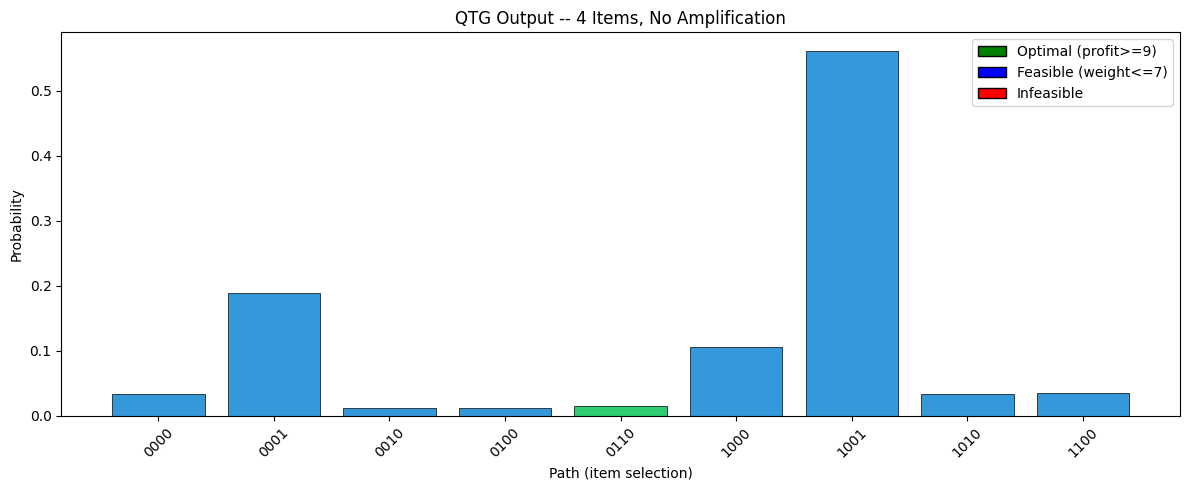

In [37]:
# ============================================================
# Cell 10 -- Histogram of bare QTG
# ============================================================

def color_bar(label, weights, profits, n_items, capacity, threshold):
    tw = sum(weights[i] for i in range(n_items) if label[n_items-1-i]=='1')
    tp = sum(profits[i] for i in range(n_items) if label[n_items-1-i]=='1')
    if tp >= threshold and tw <= capacity: return '#2ecc71'
    elif tw <= capacity:                  return '#3498db'
    else:                                 return '#e74c3c'

labels = sorted(path_probs.keys())
colors = [color_bar(l, weights, profits, n_items, capacity, threshold)
          for l in labels]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(labels, [path_probs.get(l,0) for l in labels],
       color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Path (item selection)')
ax.set_ylabel('Probability')
ax.set_title('QTG Output -- 4 Items, No Amplification')
ax.legend(handles=[
    Patch(facecolor='green', edgecolor='black', label=f'Optimal (profit>={threshold})'),
    Patch(facecolor='blue', edgecolor='black', label=f'Feasible (weight<={capacity})'),
    Patch(facecolor='red', edgecolor='black', label='Infeasible'),
], loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part B -- Amplitude amplification with multiple Grover iterations

sweep from 0 to 5 Grover iterations to see how the probability
of the optimal solution evolves. For this instance (9 feasible states,
1 marked), the theoretical optimum is around 2-3 iterations.




In [38]:
# ============================================================
# Cell 11 -- Build amplified circuit with k Grover iterations
# ============================================================
#
# For k iterations the circuit structure is:
#
#   QTG -> [ Oracle -> QTG^dag -> S_0 -> QTG ] x k -> Measure
#
# k=0 is just the bare QTG (no amplification).

def build_amplified_circuit(k_iters, qtg_circ, n_items, n_cap,
                            n_prof, capacity, threshold):
    """Return a measurement-ready circuit with k Grover iterations."""

    path_reg = QuantumRegister(n_items, 'path')
    cap_reg  = QuantumRegister(n_cap,   'cap')
    prof_reg = QuantumRegister(n_prof,  'prof')
    anc_reg  = QuantumRegister(1,       'anc')
    c_path   = ClassicalRegister(n_items, 'c_path')
    c_prof   = ClassicalRegister(n_prof,  'c_prof')

    qc = QuantumCircuit(path_reg, cap_reg, prof_reg, anc_reg,
                        c_path, c_prof)

    # qubit index lists
    all_q   = list(range(n_items + n_cap + n_prof + 1))
    prof_q  = list(range(n_items + n_cap, n_items + n_cap + n_prof))
    anc_idx = n_items + n_cap + n_prof

    # gates
    qtg_gate = qtg_circ.to_gate(label='QTG')
    qtg_inv  = qtg_gate.inverse()
    qtg_inv.label = 'QTG_dag'

    # Step 1: initial QTG
    qc.append(qtg_gate, all_q)

    # Steps 2-5: repeat k times
    for _ in range(k_iters):
        qc.barrier()
        # Oracle: phase-flip states with profit >= threshold
        threshold_oracle(qc, prof_q, anc_idx, threshold, n_prof)
        qc.barrier()
        # QTG^dag: undo state preparation
        qc.append(qtg_inv, all_q)
        qc.barrier()
        # Reflect about |0...0>  
        reflect_zero(qc, all_q)
        qc.barrier()
        # QTG: redo state preparation
        qc.append(qtg_gate, all_q)

    # Measure
    qc.measure(path_reg, c_path)
    qc.measure(prof_reg, c_prof)

    return qc

print('build_amplified_circuit() defined.')

build_amplified_circuit() defined.


In [33]:
# ============================================================
# Cell 12 -- Sweep over Grover iterations 0..5
# ============================================================

max_iters = 5
shots = 50000
sampler = AerSampler()

all_path_probs = {}   # k -> {path_bitstring: probability}

for k in range(max_iters + 1):
    print(f'Running k={k} ...', end=' ')
    qc_k = build_amplified_circuit(k, qtg_circ, n_items, n_cap,
                                   n_prof, capacity, threshold)
    job_k = sampler.run([qc_k], shots=shots)
    counts_k = job_k.result().quasi_dists[0].binary_probabilities()

    pp = {}
    for bitstr, prob in counts_k.items():
        path_bits = bitstr[n_prof:]
        pp[path_bits] = pp.get(path_bits, 0) + prob

    all_path_probs[k] = pp

    opt_prob = pp.get('0110', 0)
    greedy_prob = pp.get('1001', 0)
    print(f'P(optimal 0110) = {opt_prob:.4f},  '
          f'P(greedy 1001) = {greedy_prob:.4f}')

print('\nSweep complete.')

Running k=0 ... P(optimal 0110) = 0.0160,  P(greedy 1001) = 0.5600
Running k=1 ... P(optimal 0110) = 0.1353,  P(greedy 1001) = 0.4939
Running k=2 ... P(optimal 0110) = 0.3470,  P(greedy 1001) = 0.3746
Running k=3 ... P(optimal 0110) = 0.5937,  P(greedy 1001) = 0.2337
Running k=4 ... P(optimal 0110) = 0.8162,  P(greedy 1001) = 0.1049
Running k=5 ... P(optimal 0110) = 0.9634,  P(greedy 1001) = 0.0212

Sweep complete.


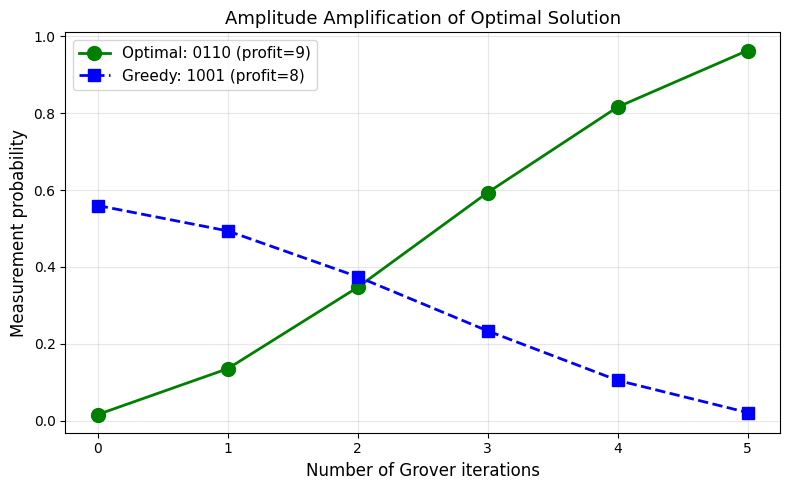

In [39]:
# ============================================================
# Cell 13 -- Plot: probability of optimal vs iterations
# ============================================================

ks = list(range(max_iters + 1))
opt_probs = [all_path_probs[k].get('0110', 0) for k in ks]
greedy_probs = [all_path_probs[k].get('1001', 0) for k in ks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, opt_probs, 'go-', markersize=10, linewidth=2,
        label='Optimal: 0110 (profit=9)')
ax.plot(ks, greedy_probs, 'bs--', markersize=8, linewidth=2,
        label='Greedy: 1001 (profit=8)')
ax.set_xlabel('Number of Grover iterations', fontsize=12)
ax.set_ylabel('Measurement probability', fontsize=12)
ax.set_title('Amplitude Amplification of Optimal Solution', fontsize=13)
ax.set_xticks(ks)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

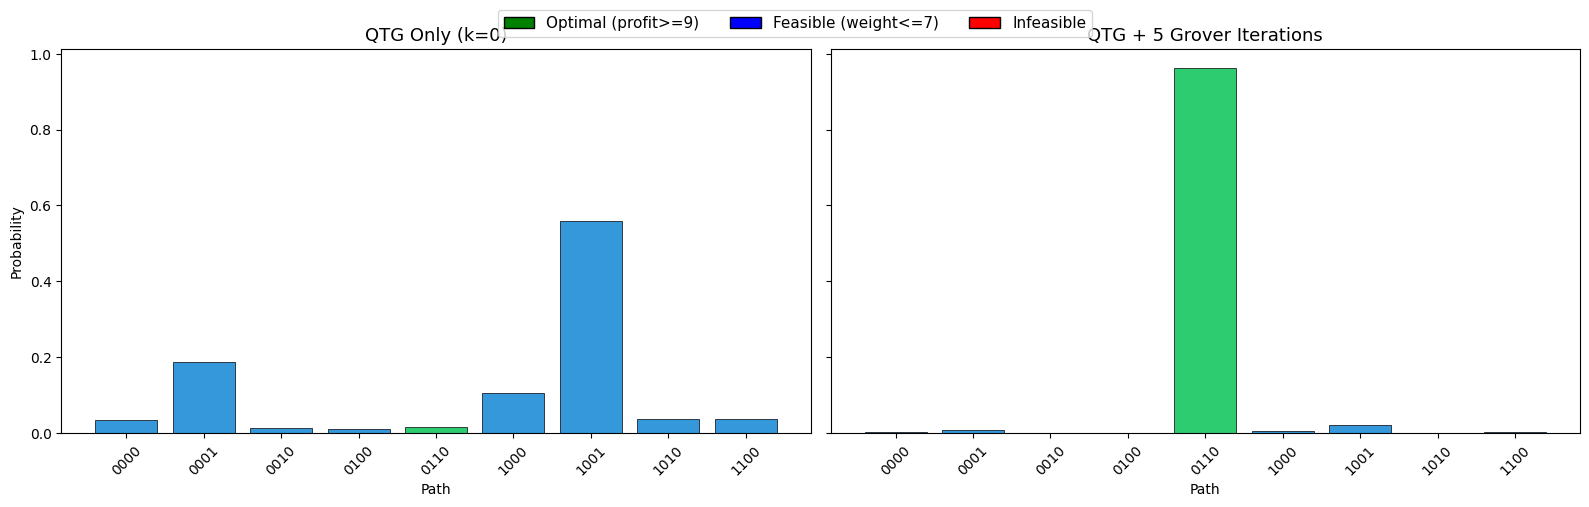

iteration count: k=5


In [42]:
# ============================================================
# Cell 14 -- Side-by-side: k=0 vs k=5
# ============================================================

best_k = max(range(max_iters+1),
             key=lambda k: all_path_probs[k].get('0110', 0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

all_labels = sorted(set().union(*[pp.keys() for pp in all_path_probs.values()]))
colors = [color_bar(l, weights, profits, n_items, capacity, threshold)
          for l in all_labels]

# Left: k=0 (bare QTG)
p0 = [all_path_probs[0].get(l, 0) for l in all_labels]
ax1.bar(all_labels, p0, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('QTG Only (k=0)', fontsize=13)
ax1.set_xlabel('Path')
ax1.set_ylabel('Probability')
ax1.tick_params(axis='x', rotation=45)

# Right:  k=5
pb = [all_path_probs[best_k].get(l, 0) for l in all_labels]
ax2.bar(all_labels, pb, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title(f'QTG + {best_k} Grover Iterations', fontsize=13)
ax2.set_xlabel('Path')
ax2.tick_params(axis='x', rotation=45)

fig.legend(handles=[
    Patch(facecolor='green', edgecolor='black', label=f'Optimal (profit>={threshold})'),
    Patch(facecolor='blue', edgecolor='black', label=f'Feasible (weight<={capacity})'),
    Patch(facecolor='red', edgecolor='black', label='Infeasible'),
], loc='upper center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

print(f'iteration count: k={best_k}')